The task in this notebook is to train a network which, given an image of a star, will calculate both the number of points on the star, as well as its width.

Thus this will be a multi-task network, performing two completely different tasks simultaneously.


In [1]:
#%% import stuff:

import matplotlib.pyplot as plt
import numpy as np
import pickle
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

The cell below assumes you have already downloaded the dataset from brightspace, and put it in your google drive folder. It demonstrates how to use google drive together with a colab notebook.

In [2]:
import os
import pickle

# Step 1: Check file exists
path = '/home/stefan_stringer/FinalSemester/Deep Learning/Week 6/starData.p'
print(f"Path exists: {os.path.exists(path)}")

# Step 2: List dir contents
dir_path = os.path.dirname(path)
print(f"Directory contents: {os.listdir(dir_path)}")

# Step 3: Try loading with error catching
try:
    temp = pickle.load(open(path, 'rb'))
    print(f"Keys in temp: {temp.keys()}")
    print(f"'X' shape: {temp['X'].shape if 'X' in temp else 'MISSING'}")
    print(f"'y' shape: {temp['y'].shape if 'y' in temp else 'MISSING'}")
except Exception as e:
    print(f"Load failed: {type(e).__name__}: {e}")


Path exists: True
Directory contents: ['starData.p', 'w6_MTL_star_student_edition.ipynb', 'hymenoptera_data.zip', 'w6_transfer2_students.ipynb', 'hymenoptera_data']
Keys in temp: dict_keys(['X', 'y'])
'X' shape: torch.Size([2000, 1, 100, 100])
'y' shape: torch.Size([2000, 2])


In [3]:
temp=pickle.load(open('/home/stefan_stringer/FinalSemester/Deep Learning/Week 6/starData.p','rb'))
X=temp['X']
y=temp['y']


tensor([5.0000, 3.1239])


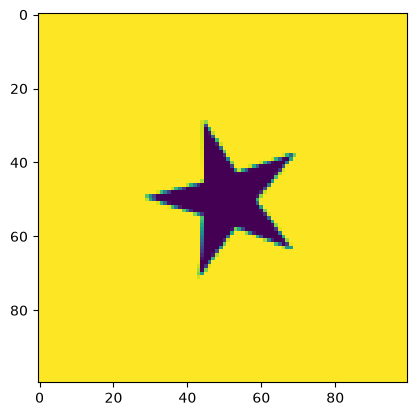

In [4]:
#Let's plot an example
idx=125
plt.imshow(np.squeeze(X[125,:,:,:],axis=0))
print(y[idx,:]) #first column is number of points, second is size of the star

In [5]:
#%% make datasets & loaders

#split in val and train
train_size = int(0.8 * len(X))
indices = torch.randperm(len(X)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

#make datasets (TensorDataset will do)
train_dataset = TensorDataset(X[train_indices], y[train_indices])
val_dataset = TensorDataset(X[val_indices], y[val_indices])

#make dataloaders
batch_size = 8  # Match what you used earlier with resnet

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
}

In [6]:
#%% make network

#something simple like cnn-cnn-fc-relu-fc will do
class StarNet(nn.Module):
    def __init__(self):
        super(StarNet, self).__init__()
        
        # CNN Block 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 100x100 -> 50x50
        
        # CNN Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 50x50 -> 25x25
        
        # Feature flattening calculation
        # After pool2: 64 channels × 25 × 25
        self.fc1_input = 64 * 25 * 25
        
        # FC layers with ReLU
        self.fc1 = nn.Linear(self.fc1_input, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 2)  # 2 outputs: [points, star_size]
        
        # Optional dropout for regularization
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        # CNN layers
        x = self.pool1(F.relu(self.conv1(x)))  # [B, 32, 50, 50]
        x = self.pool2(F.relu(self.conv2(x)))  # [B, 64, 25, 25]
        
        # Flatten
        x = x.view(x.size(0), -1)  # [B, 64*25*25]
        
        # FC layers
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)  # [B, 2]
        
        return x

# Instantiate network
# someNetwork = StarNet()


#testing:
testData=torch.rand((1,1,100,100))
testNet=StarNet()
testNet.forward(testData)

tensor([[0.0291, 0.0770]], grad_fn=<AddmmBackward0>)

In [7]:
#%% define loss'es
loss1 = nn.MSELoss()
loss2 = nn.MSELoss()
# Combined loss - weight each task appropriately
# Adjust weights based on which task matters more or balances gradients
lambda1 = 1.0  # Weight for classification
lambda2 = 1.0  # Weight for regression
loss_fn = lambda preds, targets: (
    lambda1 * loss1(preds[:, 0], targets[:, 0]) + 
    lambda2 * loss2(preds[:, 1], targets[:, 1])
)

In [8]:
#%% train & validate
# Set hyperparameters
nEpoch = 50  # Adjust based on validation performance
lr = 0.001   # Learning rate for optimizer
batch_size = 8

net=StarNet()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = net.to(device)
optimizer=torch.optim.Adam(net.parameters(), lr=lr)

train_losses = []
val_losses = []

for iEpoch in range(nEpoch):
    # Training Phase
    net.train()
    epoch_train_loss = 0.0
    num_batches = 0
    
    for xbatch, ybatch in dataloaders['train']:
        xbatch = xbatch.to(device)
        ybatch = ybatch.to(device)
        
        optimizer.zero_grad()
        predictions = net(xbatch)
        
        batch_loss = loss_fn(predictions, ybatch)
        
        batch_loss.backward()
        optimizer.step()
        
        epoch_train_loss += batch_loss.item()
        num_batches += 1
    
    avg_train_loss = epoch_train_loss / num_batches
    train_losses.append(avg_train_loss)
    
    # Validation Phase
    net.eval()
    epoch_val_loss = 0.0
    num_val_batches = 0
    
    with torch.no_grad():
        for xbatch, ybatch in dataloaders['val']:
            xbatch = xbatch.to(device)
            ybatch = ybatch.to(device)
            
            predictions = net(xbatch)
            batch_loss = loss_fn(predictions, ybatch)
            
            epoch_val_loss += batch_loss.item()
            num_val_batches += 1
    
    avg_val_loss = epoch_val_loss / num_val_batches
    val_losses.append(avg_val_loss)
    
    print(f"{iEpoch + 1:<6} {avg_train_loss:<12.4f} {avg_val_loss:<12.4f}")

print("\n✓ Training complete!")

1      9151.2575    3.0782      
2      5.8524       1.5106      
3      3.9385       1.5073      
4      3.2620       1.1267      
5      3.1832       1.3287      
6      2.8024       0.8908      
7      2.7873       0.9630      
8      2.5938       0.7130      
9      2.2475       0.6384      
10     2.5253       0.6697      
11     2.2846       0.8162      
12     2.3698       0.6738      
13     2.1501       0.8402      
14     2.0695       0.4744      
15     2.0266       0.8258      
16     2.0092       0.8735      
17     1.8969       0.6100      
18     2.0285       0.4083      
19     2.1356       0.8683      
20     1.9260       0.7985      
21     2.1741       0.4934      
22     1.8632       0.6556      
23     1.6538       0.3842      
24     1.7587       0.3259      
25     1.5335       0.8973      
26     1.5683       0.4276      
27     1.5310       0.5646      
28     1.5290       0.4592      
29     1.4977       0.4360      
30     1.5618       0.4623      
31     1.4

  → Processing training batches...
  → Processing validation batches...
✓ Collected 1600 train samples, 400 val samples



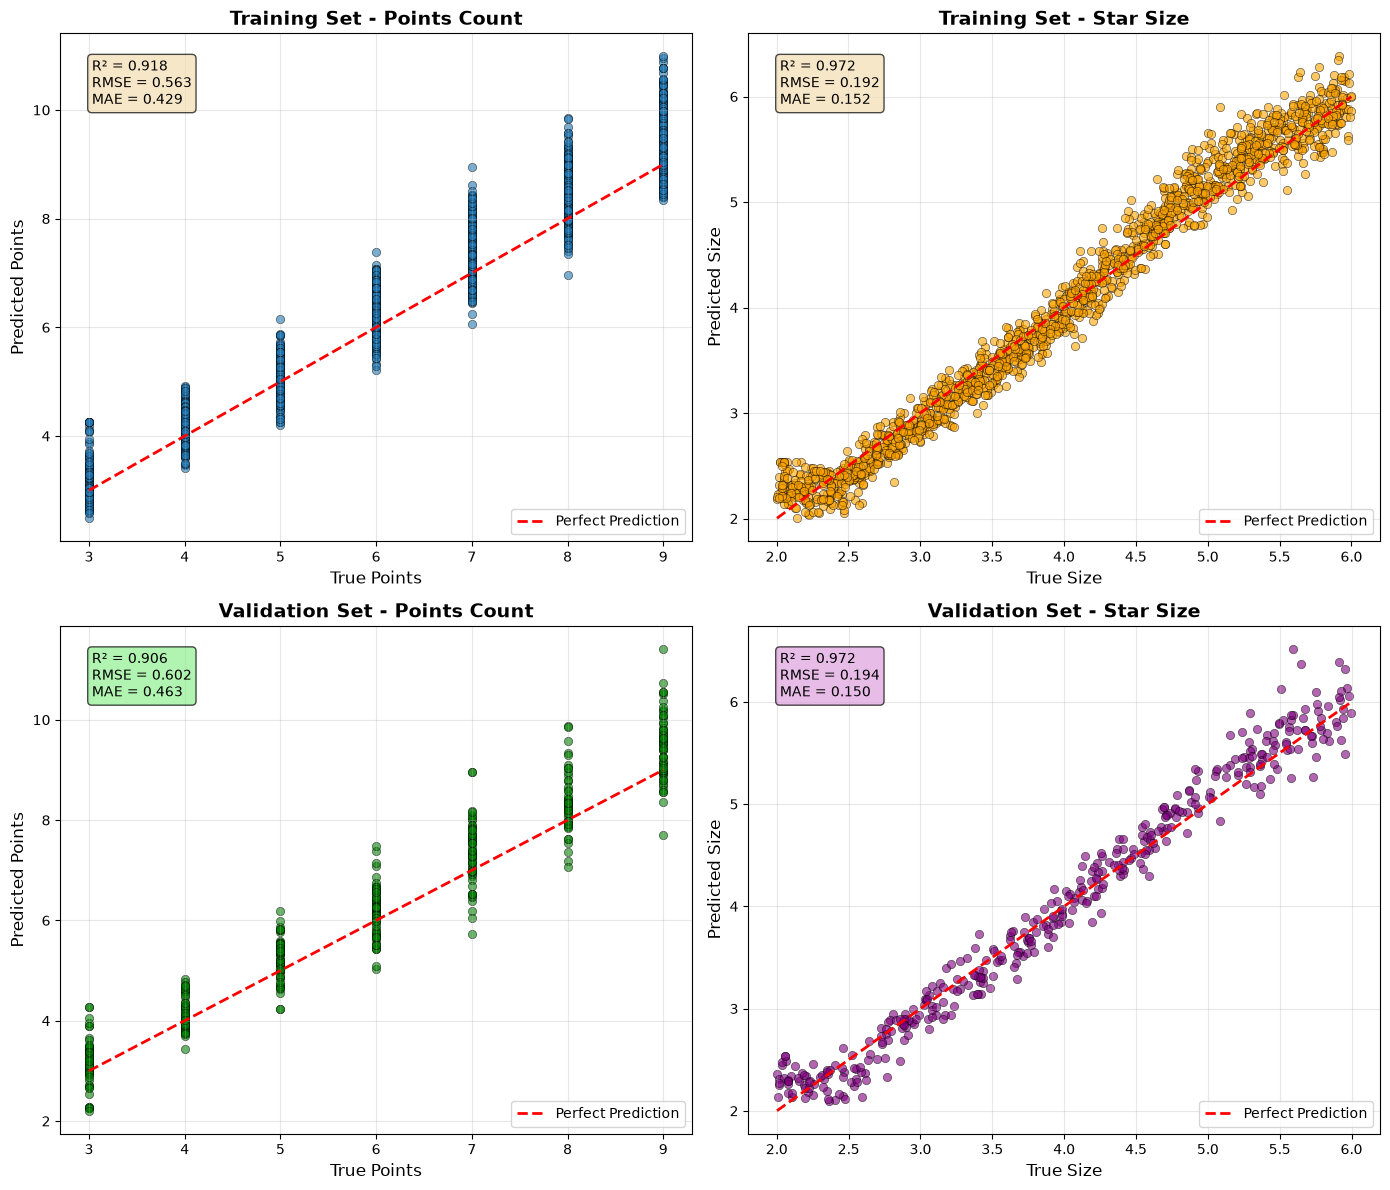

                    MULTI-TASK MODEL EVALUATION SUMMARY
----------------------------------------------------------------------
| Metric          | Train Points|  Val Points |  Train Size |   Val Size   |
| R² Score        |    0.9180   |    0.9061   |    0.9722   |    0.9722    |
| RMSE            |    0.5628   |    0.6018   |    0.1919   |    0.1943    |
| MAE             |    0.4286   |    0.4629   |    0.1516   |    0.1505    |
| Variance Captured (%)|    91.8%    |    90.6%    |    97.2%    |    97.2%     |
----------------------------------------------------------------------

📈 VARIANCE CAPTURED:
  Training:   Points=91.8% variance, Size=97.2% variance
  Validation: Points=90.6% variance, Size=97.2% variance

⚠️  OVERFITTING CHECK:
  ✓  Points task: Train-val gap = 1.2% (good generalization)
  ✓  Size task: Train-val gap = -0.0% (good generalization)

✓ Overall: Good generalization! No significant overfitting detected.


In [11]:
# %% evaluate (FIXED - CPU conversion)
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set model to evaluation mode
net.eval()

# Containers for predictions and targets
train_pred_points = []
train_pred_size = []
train_true_points = []
train_true_size = []

val_pred_points = []
val_pred_size = []
val_true_points = []
val_true_size = []

print("Collecting predictions...")

with torch.no_grad():
    # Evaluate on training set
    print("  → Processing training batches...")
    for xbatch, ybatch in dataloaders['train']:
        xbatch = xbatch.to(device)
        ybatch = ybatch.to(device)
        predictions = net(xbatch)
        
        # CRITICAL FIX: Move to CPU BEFORE appending
        train_pred_points.append(predictions[:, 0].cpu())
        train_pred_size.append(predictions[:, 1].cpu())
        train_true_points.append(ybatch[:, 0].cpu())
        train_true_size.append(ybatch[:, 1].cpu())
    
    # Evaluate on validation set
    print("  → Processing validation batches...")
    for xbatch, ybatch in dataloaders['val']:
        xbatch = xbatch.to(device)
        ybatch = ybatch.to(device)
        predictions = net(xbatch)
        
        # CRITICAL FIX: Move to CPU BEFORE appending
        val_pred_points.append(predictions[:, 0].cpu())
        val_pred_size.append(predictions[:, 1].cpu())
        val_true_points.append(ybatch[:, 0].cpu())
        val_true_size.append(ybatch[:, 1].cpu())

# Concatenate all batches (now all tensors are on CPU)
train_pred_points = torch.cat(train_pred_points).numpy()
train_pred_size = torch.cat(train_pred_size).numpy()
train_true_points = torch.cat(train_true_points).numpy()
train_true_size = torch.cat(train_true_size).numpy()

val_pred_points = torch.cat(val_pred_points).numpy()
val_pred_size = torch.cat(val_pred_size).numpy()
val_true_points = torch.cat(val_true_points).numpy()
val_true_size = torch.cat(val_true_size).numpy()

print(f"✓ Collected {len(train_true_points)} train samples, {len(val_true_points)} val samples\n")

# =====================
# Scatter Plots
# =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Training Set ---
# Output 1: Number of points (prediction vs actual)
ax = axes[0, 0]
ax.scatter(train_true_points, train_pred_points, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.plot([train_true_points.min(), train_true_points.max()], 
        [train_true_points.min(), train_true_points.max()], 
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('True Points', fontsize=12)
ax.set_ylabel('Predicted Points', fontsize=12)
ax.set_title('Training Set - Points Count', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
r2_train_points = r2_score(train_true_points, train_pred_points)
rmse_train_points = np.sqrt(mean_squared_error(train_true_points, train_pred_points))
mae_train_points = mean_absolute_error(train_true_points, train_pred_points)
ax.text(0.05, 0.95, f'R² = {r2_train_points:.3f}\nRMSE = {rmse_train_points:.3f}\nMAE = {mae_train_points:.3f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Output 2: Star size (prediction vs actual)
ax = axes[0, 1]
ax.scatter(train_true_size, train_pred_size, alpha=0.6, edgecolors='k', linewidth=0.5, color='orange')
ax.plot([train_true_size.min(), train_true_size.max()], 
        [train_true_size.min(), train_true_size.max()], 
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('True Size', fontsize=12)
ax.set_ylabel('Predicted Size', fontsize=12)
ax.set_title('Training Set - Star Size', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
r2_train_size = r2_score(train_true_size, train_pred_size)
rmse_train_size = np.sqrt(mean_squared_error(train_true_size, train_pred_size))
mae_train_size = mean_absolute_error(train_true_size, train_pred_size)
ax.text(0.05, 0.95, f'R² = {r2_train_size:.3f}\nRMSE = {rmse_train_size:.3f}\nMAE = {mae_train_size:.3f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# --- Validation Set ---
# Output 1: Number of points
ax = axes[1, 0]
ax.scatter(val_true_points, val_pred_points, alpha=0.6, edgecolors='k', linewidth=0.5, color='green')
ax.plot([val_true_points.min(), val_true_points.max()], 
        [val_true_points.min(), val_true_points.max()], 
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('True Points', fontsize=12)
ax.set_ylabel('Predicted Points', fontsize=12)
ax.set_title('Validation Set - Points Count', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
r2_val_points = r2_score(val_true_points, val_pred_points)
rmse_val_points = np.sqrt(mean_squared_error(val_true_points, val_pred_points))
mae_val_points = mean_absolute_error(val_true_points, val_pred_points)
ax.text(0.05, 0.95, f'R² = {r2_val_points:.3f}\nRMSE = {rmse_val_points:.3f}\nMAE = {mae_val_points:.3f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Output 2: Star size
ax = axes[1, 1]
ax.scatter(val_true_size, val_pred_size, alpha=0.6, edgecolors='k', linewidth=0.5, color='purple')
ax.plot([val_true_size.min(), val_true_size.max()], 
        [val_true_size.min(), val_true_size.max()], 
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('True Size', fontsize=12)
ax.set_ylabel('Predicted Size', fontsize=12)
ax.set_title('Validation Set - Star Size', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
r2_val_size = r2_score(val_true_size, val_pred_size)
rmse_val_size = np.sqrt(mean_squared_error(val_true_size, val_pred_size))
mae_val_size = mean_absolute_error(val_true_size, val_pred_size)
ax.text(0.05, 0.95, f'R² = {r2_val_size:.3f}\nRMSE = {rmse_val_size:.3f}\nMAE = {mae_val_size:.3f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='plum', alpha=0.7))

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================
# Summary Statistics Table
# =====================
print("=" * 70)
print(" " * 20 + "MULTI-TASK MODEL EVALUATION SUMMARY")
print("=" * 70)

table_data = [
    ['Metric', 'Train Points', 'Val Points', 'Train Size', 'Val Size'],
    ['R² Score', f'{r2_train_points:.4f}', f'{r2_val_points:.4f}', f'{r2_train_size:.4f}', f'{r2_val_size:.4f}'],
    ['RMSE', f'{rmse_train_points:.4f}', f'{rmse_val_points:.4f}', f'{rmse_train_size:.4f}', f'{rmse_val_size:.4f}'],
    ['MAE', f'{mae_train_points:.4f}', f'{mae_val_points:.4f}', f'{mae_train_size:.4f}', f'{mae_val_size:.4f}'],
    ['Variance Captured (%)', f'{r2_train_points*100:.1f}%', f'{r2_val_points*100:.1f}%', f'{r2_train_size*100:.1f}%', f'{r2_val_size*100:.1f}%']
]

for i, row in enumerate(table_data):
    if i == 0:
        print("-" * 70)
    print(f"| {row[0]:<16}| {row[1]:^12}| {row[2]:^12}| {row[3]:^12}| {row[4]:^12} |")

print("-" * 70)

# =====================
# Overfitting Analysis
# =====================
gap_points = r2_train_points - r2_val_points
gap_size = r2_train_size - r2_val_size

print("\n📈 VARIANCE CAPTURED:")
print(f"  Training:   Points={r2_train_points*100:.1f}% variance, Size={r2_train_size*100:.1f}% variance")
print(f"  Validation: Points={r2_val_points*100:.1f}% variance, Size={r2_val_size*100:.1f}% variance")

print("\n⚠️  OVERFITTING CHECK:")
if gap_points > 0.15:
    print(f"  ⚠️  Points task: Train-val gap = {gap_points*100:.1f}% (potential overfitting)")
else:
    print(f"  ✓  Points task: Train-val gap = {gap_points*100:.1f}% (good generalization)")

if gap_size > 0.15:
    print(f"  ⚠️  Size task: Train-val gap = {gap_size*100:.1f}% (potential overfitting)")
else:
    print(f"  ✓  Size task: Train-val gap = {gap_size*100:.1f}% (good generalization)")

if gap_points < 0.15 and gap_size < 0.15:
    print("\n✓ Overall: Good generalization! No significant overfitting detected.")
elif gap_points > 0.3 or gap_size > 0.3:
    print("\n⚠️ Warning: Significant overfitting detected.")
    print("  Consider: more dropout, weight decay, fewer epochs, early stopping")

print("=" * 70)